In [1]:
import pandas as pd
from pathlib import Path

# Đọc dữ liệu từ file gộp
BASE_DIR = Path.cwd()
df = pd.read_csv(BASE_DIR / "merged_raw_data.csv")

# Xem 5 dòng đầu tiên
print("5 dòng dữ liệu đầu tiên:")
display(df.head())

# Kiểm tra tỉ lệ dữ liệu trống
print("\nTỉ lệ % dữ liệu trống ở mỗi cột:")
display(df.isnull().sum() / len(df) * 100)

5 dòng dữ liệu đầu tiên:


,economy,Year,Edu_Spending_GDP,GDP_per_Capita,Health_Spending_GDP,Internet_Usage,Learning_Outcome,Unemployment_Rate,Population_Total,Inflation_Rate,Trade_Openness_GDP
0,ABW,2004,5.357635,23700.631990,NaN,23.0,95.470139,NaN,95138.0,2.529129,132.430930
1,ABW,2005,5.685072,24171.837133,NaN,25.4,94.429352,NaN,97635.0,3.397787,145.050280
2,ABW,2006,5.007536,24845.658484,NaN,28.0,99.461281,NaN,99405.0,3.608024,141.042627
3,ABW,2007,4.330000,26736.308944,NaN,30.9,97.330727,NaN,100150.0,5.392568,139.972309
4,ABW,2008,4.530000,28171.909401,NaN,52.0,100.205063,NaN,100917.0,8.955987,139.110150



Tỉ lệ % dữ liệu trống ở mỗi cột:


economy                 0.000000
Year                    0.000000
Edu_Spending_GDP       20.139635
GDP_per_Capita          3.079126
Health_Spending_GDP    14.357322
Internet_Usage         17.257429
Learning_Outcome       33.100609
Unemployment_Rate      11.815252
Population_Total        0.375940
Inflation_Rate         13.175797
Trade_Openness_GDP     17.669173
dtype: float64

Bài toán phân tích dữ liệu kinh tế (Time-series data)
1. Làm sạch dữ liệu (Thừa, thiếu)
- Tại sao chọn dropna(how='all')?
Tư duy: Một dòng dữ liệu chỉ có tên nước và năm mà không có bất kỳ chỉ số kinh tế nào (GDP, lạm phát...) thì hoàn toàn vô giá trị cho mô hình máy học.

Tại sao chọn: Việc giữ lại những dòng "rỗng ruột" này chỉ làm tăng nhiễu (noise) và khiến các phép tính trung bình bị sai lệch trầm trọng.
- Tại sao chọn phương pháp Forward Fill (ffill) kết hợp Groupby?
Tư duy: Các chỉ số kinh tế vĩ mô (như tỷ lệ thất nghiệp, chi tiêu giáo dục) thường có tính quán tính cao. Nó không biến động 180 độ chỉ sau một năm.

Tại sao chọn: Nếu năm 2020 một nước chi 5% GDP cho giáo dục nhưng năm 2021 họ chưa kịp báo cáo, thì ước tính hợp lý nhất là họ vẫn chi quanh mức 5% đó.

Lưu ý quan trọng: Bắt buộc phải dùng groupby('economy'). Chúng ta không thể lấy chỉ số của Việt Nam để điền vào chỗ trống của Hoa Kỳ. Phải đảm bảo tính nhất quán của từng quốc gia.

- Tại sao chọn Backward Fill (bfill) là bước cuối?
Tư duy: ffill sẽ thất bại nếu giá trị bị thiếu nằm ngay ở năm bắt đầu của bộ dữ liệu (năm 2004).

Tại sao chọn: bfill sẽ lấy giá trị của năm sớm nhất có số liệu (ví dụ 2005) để lấp vào chỗ trống của quá khứ (2004). Đây là giải pháp cuối cùng để đảm bảo bộ dữ liệu "kín" hoàn toàn, sẵn sàng cho các thuật toán yêu cầu không có giá trị rỗng.

In [2]:
import pandas as pd
from pathlib import Path

# 1. Đọc dữ liệu từ file gộp
BASE_DIR = Path.cwd()
df = pd.read_csv(BASE_DIR / "merged_raw_data.csv")

print("--- TRƯỚC KHI LÀM SẠCH ---")
print("Tổng số ô trống (NaN) ban đầu:", df.isnull().sum().sum())

# Tạo một bản sao để thao tác an toàn
df_cleaned = df.copy()

# 2. Bỏ các dòng trùng lặp (nếu có)
df_cleaned.drop_duplicates(inplace=True)

# 3. Xác định danh sách các cột chỉ số (loại trừ 'economy' và 'Year')
indicator_cols = [col for col in df_cleaned.columns if col not in ['economy', 'Year']]

# 4. Xóa các dòng mà TẤT CẢ các chỉ số đều bị trống
df_cleaned.dropna(subset=indicator_cols, how='all', inplace=True)

# 5. Điền xuôi (Forward Fill) theo từng quốc gia để lấp lỗ hổng dữ liệu
df_cleaned[indicator_cols] = df_cleaned.groupby('economy')[indicator_cols].ffill()

# 6. Điền ngược (Backward Fill) theo từng quốc gia để lấp nốt những năm đầu tiên bị thiếu
df_cleaned[indicator_cols] = df_cleaned.groupby('economy')[indicator_cols].bfill()

# 7. Quét dọn lần cuối: Xóa những dòng vẫn còn rỗng 
# (Xảy ra khi một quốc gia không báo cáo BẤT KỲ số liệu nào trong suốt 20 năm)
df_cleaned.dropna(inplace=True)

print("\n--- SAU KHI LÀM SẠCH ---")
print("Tổng số ô trống (NaN) còn lại:", df_cleaned.isnull().sum().sum())

# Xem thử 5 dòng đầu tiên của dữ liệu "sạch"
display(df_cleaned.head())

--- TRƯỚC KHI LÀM SẠCH ---
Tổng số ô trống (NaN) ban đầu: 7316

--- SAU KHI LÀM SẠCH ---
Tổng số ô trống (NaN) còn lại: 0


,economy,Year,Edu_Spending_GDP,GDP_per_Capita,Health_Spending_GDP,Internet_Usage,Learning_Outcome,Unemployment_Rate,Population_Total,Inflation_Rate,Trade_Openness_GDP
21,AFE,2004,4.432125,989.015464,6.069927,1.8,55.472919,7.278522,450928044.0,5.023421,55.901469
22,AFE,2005,4.363507,1126.297323,5.908981,1.8,57.719421,7.100414,463076637.0,8.558038,58.658301
23,AFE,2006,4.299226,1235.266608,5.911158,1.9,59.837051,7.035601,475606210.0,8.898164,59.221197
24,AFE,2007,4.164000,1381.552597,5.925114,2.7,61.481861,6.980589,488580707.0,8.450775,64.926552
25,AFE,2008,4.103148,1447.545754,5.801854,3.0,64.504387,6.959262,502070763.0,12.566645,72.113953


Bước 2: Scaling
Chọn Standardization (Z-score) thay vì Min-max scaling (Normalization) vì phương pháp 2 cực kì nhạy cảm với các Outliers (X_norm sẽ ép dữ liệu về dạng 0,1 VD: tỷ lệ lạm phát của Zimbawe vs Japan)



In [3]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

print("--- BẮT ĐẦU BƯỚC 2: CHUẨN HÓA DỮ LIỆU ---")

# 1. Tạo bản sao để chứa dữ liệu đã chuẩn hóa
df_scaled = df_cleaned.copy()

# 2. Xác định các cột cần chuẩn hóa (Chỉ lấy các chỉ số kinh tế, BỎ QUA 'economy' và 'Year')
# Lấy lại danh sách indicator_cols từ bước 1
indicator_cols = [col for col in df_cleaned.columns if col not in ['economy', 'Year']]

# 3. Khởi tạo phương pháp StandardScaler
scaler = StandardScaler()

# 4. Thực hiện chuẩn hóa và gán lại vào dataframe
df_scaled[indicator_cols] = scaler.fit_transform(df_cleaned[indicator_cols])

# Xem kết quả: Các con số khổng lồ đã biến mất
print("Dữ liệu sau khi chuẩn hóa (Standardization):")
display(df_scaled.head())

# Kiểm tra thử trung bình (mean) và độ lệch chuẩn (std) của một cột bất kỳ
print("\nKiểm tra cột GDP_per_Capita:")
print(f"Mean (Kỳ vọng) ≈ {df_scaled['GDP_per_Capita'].mean():.2f}")
print(f"Std (Độ lệch chuẩn) ≈ {df_scaled['GDP_per_Capita'].std():.2f}")

--- BẮT ĐẦU BƯỚC 2: CHUẨN HÓA DỮ LIỆU ---
Dữ liệu sau khi chuẩn hóa (Standardization):


,economy,Year,Edu_Spending_GDP,GDP_per_Capita,Health_Spending_GDP,Internet_Usage,Learning_Outcome,Unemployment_Rate,Population_Total,Inflation_Rate,Trade_Openness_GDP
21,AFE,2004,0.296483,-0.591726,-0.018172,-1.280971,-1.751822,-0.001388,0.168336,-0.110471,-0.557570
22,AFE,2005,0.253050,-0.584567,-0.076180,-1.280971,-1.626891,-0.035566,0.181650,0.054160,-0.498879
23,AFE,2006,0.212361,-0.578884,-0.075396,-1.277763,-1.509127,-0.048003,0.195382,0.070002,-0.486896
24,AFE,2007,0.126765,-0.571255,-0.070366,-1.252099,-1.417656,-0.058560,0.209601,0.049164,-0.365433
25,AFE,2008,0.088247,-0.567814,-0.114791,-1.242475,-1.249569,-0.062652,0.224386,0.240868,-0.212418



Kiểm tra cột GDP_per_Capita:
Mean (Kỳ vọng) ≈ -0.00
Std (Độ lệch chuẩn) ≈ 1.00


Khám phá dữ liệu (EDA - Exploratory Data Analysis)
Bây giờ dữ liệu đã "sạch và chuẩn", chúng ta hãy bắt đầu vẽ biểu đồ để tìm ra những thông tin thú vị (Insight). Bước đầu tiên của EDA thường là xem xét sự phân bố của các biến.

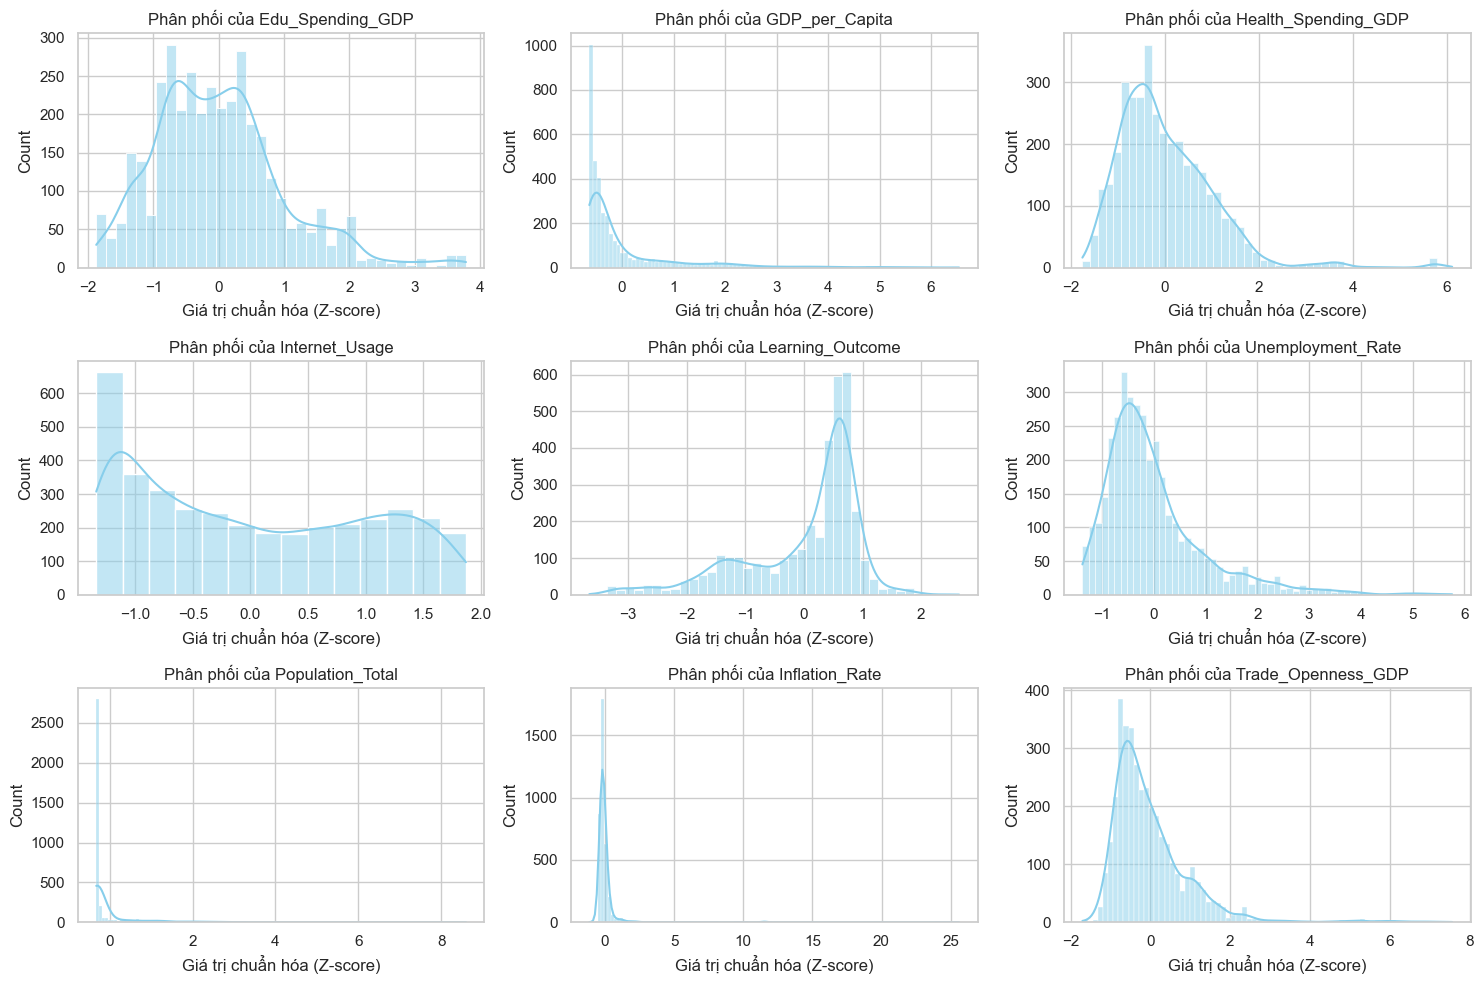

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết kế phong cách biểu đồ
sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))

# Vẽ biểu đồ phân phối cho tất cả các chỉ số
# Chúng ta dùng dữ liệu df_scaled để thấy rõ hiệu quả của chuẩn hóa
for i, col in enumerate(indicator_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df_scaled[col], kde=True, color='skyblue')
    plt.title(f'Phân phối của {col}')
    plt.xlabel('Giá trị chuẩn hóa (Z-score)')

plt.tight_layout()
plt.show()

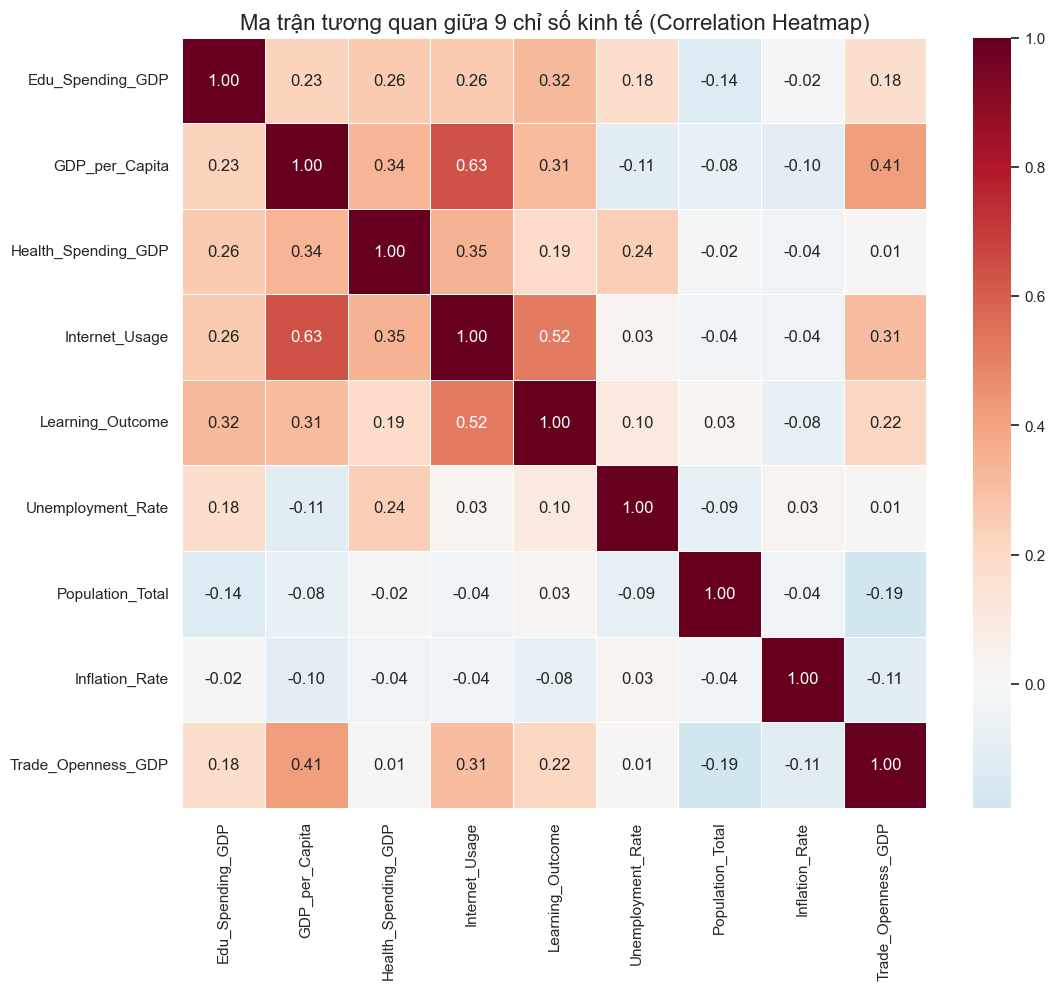

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính toán ma trận tương quan (Correlation Matrix)
# Chỉ tính toán trên các cột chỉ số kinh tế
corr_matrix = df_cleaned[indicator_cols].corr()

# 2. Vẽ biểu đồ nhiệt (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)

plt.title('Ma trận tương quan giữa 9 chỉ số kinh tế (Correlation Heatmap)', fontsize=16)
plt.show()

Trong thống kê, hệ số tương quan nằm trong khoảng từ -1 đến 1:

Gần 1: Tương quan thuận mạnh (Cái này tăng, cái kia tăng theo).

Gần -1: Tương quan nghịch mạnh (Cái này tăng, cái kia giảm).

Gần 0: Không có mối quan hệ rõ rệt.

1. Mối liên kết giữa Giáo dục và Kinh tế
- Thông thường, sự tương quan này sẽ rất mạnh (> 0.7). Điều này chứng minh lý thuyết về "Vốn con người" (Human Capital): Các quốc gia có kết quả học tập cao (chất lượng lao động tốt) thường có năng suất lao động và GDP đầu người vượt trội.
2. Nghịch lý của Lạm phát (Inflation)
- Nếu lạm phát quá cao, nó gây mất ổn định vĩ mô, khiến người dân ít đầu tư vào giáo dục và làm suy giảm kinh tế thực tế.
3. Công nghệ và Sự cởi mở (Internet vs Trade)
- Thường có tương quan thuận mạnh. Các nước có độ mở thương mại cao (xuất nhập khẩu nhiều) thường phải đầu tư mạnh vào hạ tầng Internet để giao thương quốc tế. Internet không chỉ để giải trí, nó là hạ tầng của thương mại hiện đại.
4. "Bẫy" Chi tiêu Giáo dục
- Điều này gợi ý rằng hiệu quả sử dụng tiền quan trọng hơn số lượng tiền. Một số nước chi rất nhiều nhưng kết quả học tập vẫn thấp (có thể do lãng phí hoặc quản lý kém), trong khi một số nước chi vừa phải nhưng có hệ thống giáo dục cực tốt.
5. 